Ambiente Orekit caricato con successo!

Propagazione di 24.0 ore in corso (Gravita 10x10, Drag, SRP, 3rd Body)...

  RISULTATI DOPO 24 ORE DI PROPAGAZIONE PERTURBATA
Semiasse iniziale: 6678.137 km
Semiasse finale:   6673.113 km
--> Decadimento Quota (SMA): 5024.1 metri persi per il Drag
--------------------------------------------------------
Inclinazione iniz: 50.00000 deg
Inclinazione fin:  49.98181 deg
--------------------------------------------------------
RAAN iniziale:     0.000 deg
RAAN finale:       -5.496 deg
--> Drift del Nodo Ascendente causato dall'effetto J2

Generazione grafico 3D in corso...


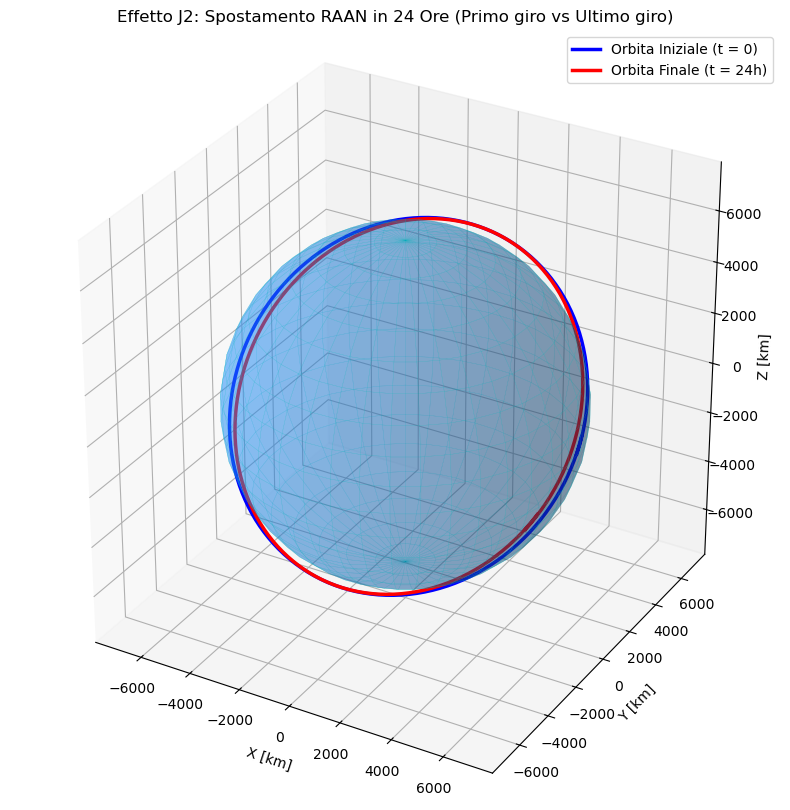

In [6]:
import math
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main') 

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState

# Importazioni per le Perturbazioni 
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

print("Ambiente Orekit caricato con successo!")

# ==========================================
# 2. DEFINIZIONE DEL TEMPO E DEI FRAME
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000() # J2000 / ECI
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True) # ECEF

# Creazione corpo della Terra ( l'atmosfera e la SRP)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)

mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. CREAZIONE DELL'ORBITA (LEO a 300 km)
# ==========================================
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + 300e3  # 300 km di quota (metri)
e = 0.001
i = math.radians(50.0)
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 850.0) # Aggiungiamo 850 kg di massa (come in GMAT)

# ==========================================
# 4. CONFIGURAZIONE DEL PROPAGATORE
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())

# Cast esplicito da Oggetto Java ad Array Double per Python
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

# ==========================================
# 5. AGGIUNTA DI TUTTE LE PERTURBAZIONI
# ==========================================
# A) Gravità Terrestre (Armoniche sferiche 10x10 per J2, J3, ecc.)
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# B) Third-Body (Sole e Luna)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

# C) Atmospheric Drag (Modello Harris-Priester)
atmosphere = HarrisPriester(sun, earth_shape)
# DragArea = 15 m^2, Cd = 2.2 (Stessi parametri di GMAT)
drag = DragForce(atmosphere, IsotropicDrag(15.0, 2.2))
propagator.addForceModel(drag)

# D) Solar Radiation Pressure (SRP)
# SRPArea = 1 m^2, Cr = 1.8
srp = SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(1.0, 1.8))
propagator.addForceModel(srp)

# ==========================================
# 6. PROPAGAZIONE DI 24 ORE
# ==========================================
duration = 24.0 * 3600.0  # 24 ore in secondi
final_date = initial_date.shiftedBy(duration)

print(f"\nPropagazione di {duration/3600} ore in corso (Gravita 10x10, Drag, SRP, 3rd Body)...")
ephemeris_generator = propagator.getEphemerisGenerator()
final_state = propagator.propagate(final_date)
final_orbit = final_state.getOrbit()

# ==========================================
# 7. RISULTATI: DECADIMENTO E VARIAZIONI
# ==========================================
# Traduciamo l'orbita finale generica in un'orbita Kepleriana
final_kep_orbit = KeplerianOrbit(final_orbit)
a_fin = final_kep_orbit.getA()
i_fin = math.degrees(final_kep_orbit.getI())
raan_fin = math.degrees(final_kep_orbit.getRightAscensionOfAscendingNode())

print("\n========================================================")
print("  RISULTATI DOPO 24 ORE DI PROPAGAZIONE PERTURBATA")
print("========================================================")
print(f"Semiasse iniziale: {a/1000:.3f} km")
print(f"Semiasse finale:   {a_fin/1000:.3f} km")
print(f"--> Decadimento Quota (SMA): {((a - a_fin)/1000)*1000:.1f} metri persi per il Drag")
print("--------------------------------------------------------")
print(f"Inclinazione iniz: {math.degrees(i):.5f} deg")
print(f"Inclinazione fin:  {i_fin:.5f} deg")
print("--------------------------------------------------------")
print(f"RAAN iniziale:     {math.degrees(raan):.3f} deg")
print(f"RAAN finale:       {raan_fin:.3f} deg")
print(f"--> Drift del Nodo Ascendente causato dall'effetto J2")
print("========================================================")

# ==========================================
# 8. VISUALIZZAZIONE 3D (INIZIALE vs FINALE)
# ==========================================
print("\nGenerazione grafico 3D in corso...")
ephemeris = ephemeris_generator.getGeneratedEphemeris()

# Il periodo di un'orbita LEO a 300km è circa 90 minuti (5400 secondi).
# Usiamo 5500 per assicurarci di chiudere il cerchio visivamente.
periodo_orbitale = 5500.0

# 1. Estrazione punti Orbita Iniziale (t=0 fino a t=90 min)
times_init = np.linspace(0, periodo_orbitale, 150)
x_init, y_init, z_init = [], [], []
for t in times_init:
    current_date = initial_date.shiftedBy(float(t))
    pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
    x_init.append(pos.getX() / 1000.0)
    y_init.append(pos.getY() / 1000.0)
    z_init.append(pos.getZ() / 1000.0)

# 2. Estrazione punti Orbita Finale (t=24h - 90 min fino a t=24h)
times_final = np.linspace(duration - periodo_orbitale, duration, 150)
x_fin, y_fin, z_fin = [], [], []
for t in times_final:
    current_date = initial_date.shiftedBy(float(t))
    pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
    x_fin.append(pos.getX() / 1000.0)
    y_fin.append(pos.getY() / 1000.0)
    z_fin.append(pos.getZ() / 1000.0)

# Creazione Plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Disegniamo la Terra con un wireframe leggero per dare il senso del volume
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

# Plot dei due singoli giri separati
ax.plot(x_init, y_init, z_init, color='blue', linewidth=2.5, label='Orbita Iniziale (t = 0)')
ax.plot(x_fin, y_fin, z_fin, color='red', linewidth=2.5, label='Orbita Finale (t = 24h)')

# Setup degli assi perfetti (fondamentale per mantenere la sfericità)
lim = R_E_km + 1500
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) # Questo comando evita che la Terra sembri un ovale!

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Effetto J2: Spostamento RAAN in 24 Ore (Primo giro vs Ultimo giro)')
ax.legend(loc='upper right')

plt.show()